<a href="https://colab.research.google.com/github/KinzaAsif2456/discoverey/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

The goal here is to turn the model output into a short list of pages that can be reviewed first. The model score gives the ranking, while the reason codes give a simple explanation for why a page was included.

The data comes from the FlyRank Hugging Face warehouse. I use the March 1–15 period as the feature window and the period starting March 16 as the outcome window.

In [1]:
#IMPORTS

import os
import json

import duckdb
from google.colab import userdata
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

In [2]:

%pip install -q duckdb huggingface_hub


In [3]:
# STEP 1 - Fetch data from starter repo
HF_TOKEN = userdata.get("HF_TOKEN")
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")

REL = "hf://datasets/FlyRank/internship-warehouse"
TABLES = {
    "dim_clients":      f"read_parquet('{REL}/dim_clients.parquet')",
    "dim_content":      f"read_parquet('{REL}/dim_content.parquet')",
    "fact_daily_march": f"read_parquet('{REL}/fact_content_daily_performance/month=2026-03/*.parquet')",
}


In [4]:
# Features must come from the period BEFORE the outcome.


FEAT_START = "2026-03-01"
FEAT_END = "2026-03-15"
OUT_START = "2026-03-16"


print("Warehouse connection ready.")
print(f"Feature window: {FEAT_START} to {FEAT_END}")
print(f"Outcome starts: {OUT_START}")

Warehouse connection ready.
Feature window: 2026-03-01 to 2026-03-15
Outcome starts: 2026-03-16


In [5]:
# STEP 2 — Build page-level features

df = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(ga4_engaged_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_engaged_sessions,

        SUM(ga4_sessions)
            FILTER (WHERE ga4_data_available)
            AS ga4_sessions,

        SUM(gsc_impressions) AS impressions_feature_window,

        SUM(gsc_clicks) AS clicks_feature_window,

        AVG(gsc_avg_position)
            FILTER (WHERE gsc_impressions > 0)
            AS avg_position

    FROM {TABLES['fact_daily_march']}

    WHERE report_date BETWEEN
        DATE '{FEAT_START}'
        AND DATE '{FEAT_END}'

    GROUP BY
        client_hash_id,
        content_hash_id

    HAVING SUM(gsc_impressions) >= 10
    """
).df()


# Calculate CTR after aggregation
df["ctr"] = (
    df["clicks_feature_window"]
    / df["impressions_feature_window"]
    * 100
)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [8]:
print("Dataset shape:", df.shape)
print("Unique clients:", df["client_id"].nunique())
print("Unique content:", df["content_id"].nunique())

display(df.head())

print("features columns:")
print(df.columns.tolist())

Dataset shape: (120513, 8)
Unique clients: 41
Unique content: 120513


,client_id,content_id,ga4_engaged_sessions,ga4_sessions,impressions_feature_window,clicks_feature_window,avg_position,ctr
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,NaN,NaN,4173.0,6.0,6.327311,0.143781
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,NaN,NaN,245.0,0.0,3.906852,0.000000
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,NaN,NaN,3705.0,3.0,6.473735,0.080972
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,NaN,NaN,2440.0,8.0,7.259861,0.327869
4,client_73cda7b4e4f265ea,content_f39be42b42a4e8f6,NaN,NaN,14.0,0.0,9.000000,0.000000


features columns:
['client_id', 'content_id', 'ga4_engaged_sessions', 'ga4_sessions', 'impressions_feature_window', 'clicks_feature_window', 'avg_position', 'ctr']


In [11]:
# Check average-position missingness

print(
    "Missing avg_position:",
    df["avg_position"].isna().sum()
)

print(
    "Zero avg_position:",
    (df["avg_position"] == 0).sum()
)

print(
    "Minimum feature-window impressions:",
    df["impressions_feature_window"].min()
)

print(
    "Rows with <10 impressions:",
    (df["impressions_feature_window"] < 10).sum()
)

Missing avg_position: 0
Zero avg_position: 38
Minimum feature-window impressions: 10.0
Rows with <10 impressions: 0


### Dataset and target

I build one row for each content page and client. The page-level performance measures are aggregated over the March 1–15 feature window.

The feature data includes Google Search Console impressions, clicks, CTR, average position, and the available GA4 session measures. The outcome is calculated separately from March 16 onward.

I define a decline when outcome-period impressions are less than 80% of the impressions observed during the feature window.

Pages with no observed outcome impressions are treated as zero outcome impressions. This is a modelling choice for this notebook and should not be interpreted as proof that the page received no traffic outside the observed data.

In [12]:
# STEP 3 — Build outcome data

outcome = con.sql(
    f"""
    SELECT
        client_hash_id AS client_id,
        content_hash_id AS content_id,

        SUM(gsc_impressions) AS impressions_outcome

    FROM {TABLES['fact_daily_march']}

    WHERE report_date >= DATE '{OUT_START}'

    GROUP BY
        client_hash_id,
        content_hash_id
    """
).df()

print("Outcome rows:", len(outcome))
print("Outcome columns:", outcome.columns.tolist())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Outcome rows: 331436
Outcome columns: ['client_id', 'content_id', 'impressions_outcome']


In [13]:
# STEP 4 — Merge and create target label

df = df.merge(
    outcome,
    on=["client_id", "content_id"],
    how="left"
)

# Pages with no observed outcome impressions
# are treated as zero outcome impressions.
df["impressions_outcome"] = (
    df["impressions_outcome"]
    .fillna(0)
)

# Decline = outcome impressions < 80% of feature-window impressions
df["is_declining_label"] = (
    df["impressions_outcome"]
    < 0.80 * df["impressions_feature_window"]
).astype(int)

print("Final dataset shape:", df.shape)

print(
    "Overall decline rate:",
    df["is_declining_label"].mean()
)

display(
    df[
        [
            "client_id",
            "content_id",
            "impressions_feature_window",
            "impressions_outcome",
            "is_declining_label"
        ]
    ].head()
)

Final dataset shape: (120513, 10)
Overall decline rate: 0.29649083501365


,client_id,content_id,impressions_feature_window,impressions_outcome,is_declining_label
0,client_73cda7b4e4f265ea,content_7a105f548d9c6916,4173.0,2350.0,1
1,client_73cda7b4e4f265ea,content_a3ea9792f793ec72,245.0,208.0,0
2,client_73cda7b4e4f265ea,content_36c36abc7650d7af,3705.0,1925.0,1
3,client_73cda7b4e4f265ea,content_a7da352b73b02668,2440.0,2504.0,0
4,client_73cda7b4e4f265ea,content_f39be42b42a4e8f6,14.0,28.0,0


### Adding page freshness

The performance table does not contain the old `freshness_tier` field directly, so I derive it from the content update date in the warehouse.

I use the same four age groups as before: `0-30`, `31-90`, `91-180`, and `181+` days. Pages without a usable update date are kept as `unknown` rather than being forced into one of the groups.


In [14]:

# STEP 5 — Add content metadata and recreate freshness


content_meta = con.sql(
    f"""
    SELECT
        content_hash_id AS content_id,
        content_updated_date,
        word_count
    FROM {TABLES['dim_content']}
    """
).df()

df = df.merge(
    content_meta,
    on="content_id",
    how="left"
)

print("Dataset shape after metadata merge:", df.shape)

print("\nMetadata columns:")
print(df[["content_id", "content_updated_date", "word_count"]].head())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Dataset shape after metadata merge: (120513, 12)

Metadata columns:
                 content_id content_updated_date  word_count
0  content_7a105f548d9c6916           2026-07-06        2123
1  content_a3ea9792f793ec72           2026-05-18        <NA>
2  content_36c36abc7650d7af           2026-05-20        2546
3  content_a7da352b73b02668           2026-07-06        2330
4  content_f39be42b42a4e8f6           2026-05-18        <NA>


In [15]:

# STEP 6 — Recreate freshness tier


REFERENCE_DATE = pd.Timestamp(FEAT_END)

df["content_updated_date"] = pd.to_datetime(
    df["content_updated_date"],
    errors="coerce"
)

df["days_since_update"] = (
    REFERENCE_DATE -
    df["content_updated_date"]
).dt.days

def assign_freshness(days):

    if pd.isna(days):
        return "unknown"

    if days <= 30:
        return "0-30"

    if days <= 90:
        return "31-90"

    if days <= 180:
        return "91-180"

    return "181+"

df["freshness_tier"] = (
    df["days_since_update"]
    .apply(assign_freshness)
)

print(
    df["freshness_tier"]
    .value_counts()
    .sort_index()
)

freshness_tier
0-30      120046
181+          39
31-90        137
91-180       291
Name: count, dtype: int64


### Rule-based signals

I use a few simple checks alongside the model score. These are not separate predictions. They are there to make the queue easier to review.

Older pages are marked as stale. Pages with a good average position but low CTR are flagged for a possible title or meta description review. Older pages with at least 5,000 impressions are given a higher-traffic stale flag.

The CTR threshold is 0.5% because CTR is calculated as clicks divided by impressions and then expressed as a percentage.

The impression thresholds below therefore refer to the aggregated impressions in the March 1–15 feature window, not to a 90-day period.


In [16]:

# STEP 7 — Recreate rule-based flags


STALE_TIERS = [
    "91-180",
    "181+"
]

CTR_THRESHOLD = 0.5

IMPRESSION_DECOY_LEVEL = 5000


df["stale_flag"] = (
    df["freshness_tier"]
    .isin(STALE_TIERS)
)

df["low_ctr_flag"] = (
    (df["avg_position"] <= 20)
    &
    (df["ctr"] < CTR_THRESHOLD)
    &
    (df["impressions_feature_window"] >= 500)
)

df["is_decoy"] = (
    (df["freshness_tier"] == "181+")
    &
    (df["impressions_feature_window"] >= IMPRESSION_DECOY_LEVEL)
)
print("Stale pages:", df["stale_flag"].sum())
print("Low CTR pages:", df["low_ctr_flag"].sum())
print("High-traffic stale pages:", df["is_decoy"].sum())

Stale pages: 330
Low CTR pages: 26583
High-traffic stale pages: 0


In [17]:
# STEP 8 — Model features

tier_order = [
    "0-30",
    "31-90",
    "91-180",
    "181+"
]

df["freshness_tier_enc"] = (
    df["freshness_tier"]
    .map({
        tier: i
        for i, tier in enumerate(tier_order)
    })
)

# Correctly identify missing average-position values.
# With the current >=10 impression floor, this is expected
# to be zero for all rows in this dataset.
df["avg_position_missing"] = (
    df["avg_position"].isna()
).astype(int)


FEATURES = [
    "freshness_tier_enc",
    "avg_position",
    "ctr",
    "impressions_feature_window",
    "avg_position_missing"
]


print("Features used by final RF:")
print(FEATURES)

print(
    "\nMissing avg_position flags:",
    df["avg_position_missing"].sum()
)

Features used by final RF:
['freshness_tier_enc', 'avg_position', 'ctr', 'impressions_feature_window', 'avg_position_missing']

Missing avg_position flags: 0


In [18]:
# STEP 9 — Prepare model inputs

df["freshness_tier_enc"] = (
    df["freshness_tier_enc"]
    .fillna(-1)
)

df["avg_position"] = (
    df["avg_position"]
    .fillna(0)
)

df["ctr"] = (
    df["ctr"]
    .fillna(0)
)

df["impressions_feature_window"] = (
    df["impressions_feature_window"]
    .fillna(0)
)


print("FEATURES:")
print(FEATURES)

print("\nMissing values:")
print(df[FEATURES].isna().sum())

print("\nMissing-position flag distribution:")
print(df["avg_position_missing"].value_counts())

FEATURES:
['freshness_tier_enc', 'avg_position', 'ctr', 'impressions_feature_window', 'avg_position_missing']

Missing values:
freshness_tier_enc            0
avg_position                  0
ctr                           0
impressions_feature_window    0
avg_position_missing          0
dtype: int64

Missing-position flag distribution:
avg_position_missing
0    120513
Name: count, dtype: int64


In [19]:
print("Missing avg_position flags:", df["avg_position_missing"].sum())

print("\nMissing values:")
print(df[FEATURES].isna().sum())

print("\nMissing-position flag distribution:")
print(df["avg_position_missing"].value_counts())

Missing avg_position flags: 0

Missing values:
freshness_tier_enc            0
avg_position                  0
ctr                           0
impressions_feature_window    0
avg_position_missing          0
dtype: int64

Missing-position flag distribution:
avg_position_missing
0    120513
Name: count, dtype: int64


### Ranking the pages

I use the Random Forest from the previous modelling work to rank the pages by estimated decline risk.

This fit uses the available labelled data to create the working queue. It is not being used to report a new validation score. The validation result I report later is the grouped cross-validation result from Week 6.


In [20]:

# STEP 10 — Fit final RF for action queue


rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    df[FEATURES],
    df["is_declining_label"]
)

# This score is ONLY used to rank the working queue.
# It is NOT a validation score.

df["model_score"] = (
    rf.predict_proba(
        df[FEATURES]
    )[:, 1]
)

print("RF fitted successfully.")

print(
    "Model score range:",
    round(df["model_score"].min(), 4),
    "to",
    round(df["model_score"].max(), 4)
)

RF fitted successfully.
Model score range: 0.0149 to 0.7475


### Building the action queue

I keep the top 200 pages after sorting by model score. Impressions are used as a secondary sort so that pages with the same or very similar scores are ordered consistently.

This is a working backlog for review, not a list of pages that must all be changed.


In [21]:

# STEP 11 — Create ranked action queue


queue_size = 200

queue_df = (
    df
    .sort_values(
        ["model_score", "impressions_feature_window"],
        ascending=[False, False]
    )
    .head(queue_size)
    .copy()
)

print("Queue size:", len(queue_df))

display(
    queue_df[
        [
            "content_id",
            "client_id",
            "model_score",
            "freshness_tier",
            "avg_position",
            "ctr",
            "impressions_feature_window"
        ]
    ].head(20)
)

Queue size: 200


,content_id,client_id,model_score,freshness_tier,avg_position,ctr,impressions_feature_window
80606,content_2f094ec88d7faa51,client_23a62021009f63c4,0.747544,0-30,41.630604,0.036718,35405.0
78322,content_54488b3c9ca74731,client_23a62021009f63c4,0.744699,0-30,41.645825,0.034152,26353.0
78814,content_87b9c790d43001dc,client_23a62021009f63c4,0.744544,0-30,42.345324,0.036474,35642.0
79235,content_e70886c63f95aa1c,client_23a62021009f63c4,0.744034,0-30,44.978593,0.030100,23256.0
77089,content_d137a0303fdb6714,client_23a62021009f63c4,0.741323,0-30,45.370872,0.023746,29479.0
78295,content_0b5d0ab50b14a4e0,client_23a62021009f63c4,0.740481,0-30,44.981021,0.026089,22998.0
80624,content_cb35c5cd43ee17d2,client_23a62021009f63c4,0.737944,0-30,42.672911,0.023606,29653.0
19564,content_3ecbd0e3911c0a35,client_23a62021009f63c4,0.736182,0-30,46.657740,0.058400,20548.0
19508,content_dd5472aea4c7aa91,client_23a62021009f63c4,0.735708,0-30,42.991742,0.062894,44519.0
79117,content_96b7f1d5f7c0c374,client_23a62021009f63c4,0.735488,0-30,45.496565,0.030177,16569.0


In [22]:

# STEP 12 — Assign reason codes


def reason_code(row):

    if row["is_decoy"]:
        return "high_traffic_stale"

    if (
        row["stale_flag"]
        and row["low_ctr_flag"]
    ):
        return "stale_and_underperforming"

    if row["avg_position_missing"]:
        return "unranked"

    if row["stale_flag"]:
        return "stale"

    if row["low_ctr_flag"]:
        return "low_ctr"

    return "model_signal_only"


queue_df["reason_code"] = (
    queue_df.apply(
        reason_code,
        axis=1
    )
)

print(
    queue_df["reason_code"]
    .value_counts()
)

reason_code
model_signal_only    200
Name: count, dtype: int64


In [23]:

# STEP 13 — Reason-code distribution


counts = (
    queue_df["reason_code"]
    .value_counts()
)

print("Reason code distribution:\n")

for reason, count in counts.items():

    percentage = (
        count /
        len(queue_df) *
        100
    )

    print(
        f"{reason}: "
        f"{count} pages "
        f"({percentage:.1f}%)"
    )

top_reason = counts.index[0]
top_count = counts.iloc[0]

top_percent = (
    top_count /
    len(queue_df) *
    100
)

print(
    f"\nMost common reason code: "
    f"{top_reason} "
    f"({top_count} pages, "
    f"{top_percent:.1f}%)"
)

Reason code distribution:

model_signal_only: 200 pages (100.0%)

Most common reason code: model_signal_only (200 pages, 100.0%)


In [24]:

# STEP 14 — Archetype → recommended action


action_map = {

    "high_traffic_stale":
        "Priority full refresh — review high-traffic aging page first",

    "stale_and_underperforming":
        "Review title + meta description first; consider deeper refresh",

    "unranked":
        "Check indexing/technical issues before content changes",

    "stale":
        "Schedule for routine content refresh",

    "low_ctr":
        "Review title + meta description for click appeal",

    "model_signal_only":
        "Manual review — verify the page before taking action"
}

queue_df["recommended_action"] = (
    queue_df["reason_code"]
    .map(action_map)
)

print(
    queue_df["recommended_action"]
    .value_counts()
)

recommended_action
Manual review — verify the page before taking action    200
Name: count, dtype: int64


**What the queue looks like**

The distribution below shows which reason codes are most common in the 200-page queue.

I use this distribution to decide where the review effort is likely to be concentrated. I don't assume beforehand that one reason code will dominate; the result should come from the current warehouse data.

### Reason codes

The model score tells me which pages are ranked higher, but it does not give an editor a useful reason for taking action. I therefore add a simple reason code based on the rule flags.

The codes are:

* **`high_traffic_stale`** — an older page with at least 5,000 impressions during the March 1–15 feature window.
* **`stale_and_underperforming`** — an older page that also has low CTR while ranking within the top 20 positions and meeting the minimum impression threshold.
* **`unranked`** — average position is recorded as 0.
* **`stale`** — an older page that does not meet the other rule conditions.
* **`low_ctr`** — low CTR with a reasonable average position and at least 500 impressions during the feature window.
* **`model_signal_only`** — the model ranked the page highly, but none of the rule-based reasons applied.

These labels are used to make the review queue easier to understand. They are not evidence that a particular editorial change will improve performance.

### Archetype → action

The reason code is used to suggest a first step for the editor. These are practical recommendations rather than automatic actions.

* **`high_traffic_stale`** → Review this page earlier because it is old and already receives substantial search traffic.
* **`stale_and_underperforming`** → Start by reviewing the title and meta description before considering a larger rewrite.
* **`unranked`** → Check indexing and other technical issues before changing the content.
* **`stale`** → Add the page to the normal content refresh backlog.
* **`low_ctr`** → Review the title and meta description for a possible snippet improvement.
* **`model_signal_only`** → Send for manual review because the rule-based checks do not explain the model ranking.

The model does not choose the editorial change itself. It only helps decide which pages should be looked at first.


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [25]:

# STEP 15 — Priority level

priority_map = {

    "high_traffic_stale": "High",

    "stale_and_underperforming": "High",

    "unranked": "High",

    "low_ctr": "Medium",

    "stale": "Medium",

    "model_signal_only": "Review"
}

queue_df["priority"] = (
    queue_df["reason_code"]
    .map(priority_map)
)

display(
    queue_df[
        [
            "content_id",
            "model_score",
            "reason_code",
            "priority",
            "recommended_action"
        ]
    ].head(20)
)

,content_id,model_score,reason_code,priority,recommended_action
80606,content_2f094ec88d7faa51,0.747544,model_signal_only,Review,Manual review — verify the page before taking ...
78322,content_54488b3c9ca74731,0.744699,model_signal_only,Review,Manual review — verify the page before taking ...
78814,content_87b9c790d43001dc,0.744544,model_signal_only,Review,Manual review — verify the page before taking ...
79235,content_e70886c63f95aa1c,0.744034,model_signal_only,Review,Manual review — verify the page before taking ...
77089,content_d137a0303fdb6714,0.741323,model_signal_only,Review,Manual review — verify the page before taking ...
78295,content_0b5d0ab50b14a4e0,0.740481,model_signal_only,Review,Manual review — verify the page before taking ...
80624,content_cb35c5cd43ee17d2,0.737944,model_signal_only,Review,Manual review — verify the page before taking ...
19564,content_3ecbd0e3911c0a35,0.736182,model_signal_only,Review,Manual review — verify the page before taking ...
19508,content_dd5472aea4c7aa91,0.735708,model_signal_only,Review,Manual review — verify the page before taking ...
79117,content_96b7f1d5f7c0c374,0.735488,model_signal_only,Review,Manual review — verify the page before taking ...


## Intended use and limits

The main use of this output is to help an editor decide which pages to review first. It is not intended to decide automatically what should be published or changed.

The model was built from a single March snapshot and the available data covers 32 clients. The grouped validation result from Week 6 was **Precision@50 = 0.872 ± 0.069**, compared with **0.788 ± 0.124** for the rule-based baseline.

Those numbers describe the earlier validation setup. They should not be treated as a guarantee that the same precision will be achieved on future pages or new clients.

I also have not tested this version on completely unseen clients, so I would want another validation check before treating it as a general solution.


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

The queue is meant to support human review, not replace it.

I flag model-signal-only pages for review because there is no simple rule-based explanation for their ranking. I also flag pages below the chosen score threshold within the 200-page queue because they are closer to the lower end of the ranking.

The percentage requiring review is calculated from the current queue rather than being fixed in advance.

In [26]:

# Mandatory human review


review_threshold = (
    queue_df["model_score"]
    .quantile(0.60)
)

queue_df["mandatory_human_review"] = (
    (queue_df["reason_code"] == "model_signal_only")
    |
    (queue_df["model_score"] < review_threshold)
)

num_review = (
    queue_df["mandatory_human_review"]
    .sum()
)

review_percent = (
    num_review /
    len(queue_df)
    * 100
)

print(
    f"{num_review} of {len(queue_df)} "
    f"queue rows require mandatory human review "
    f"({review_percent:.1f}%)."
)

200 of 200 queue rows require mandatory human review (100.0%).


In [27]:

#  No-go automation rules


queue_df["automation_allowed"] = False

print(
    "Any automatic content action allowed:",
    queue_df["automation_allowed"].any()
)

Any automatic content action allowed: False


###Human review rule
Every page should still be reviewed before an editorial change is made. The mandatory-review flag is an additional guardrail for cases where the model explanation is weaker or the score is closer to the bottom of the queue.

A high model score is not approval to make a change. An editor should still check the page and its context.

### Cost and value
The queue is also meant to help use limited editorial time sensibly.

Pages with high traffic and signs of staleness are worth looking at earlier because they already have substantial search exposure. Low-CTR pages may need a smaller first step, such as checking the title and meta description. Unranked pages should go through a technical check before editorial work.

This is only an effort-prioritisation rule. The model does not estimate revenue, traffic recovery, or the financial value of an individual page.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

This queue is based on one snapshot, so I would not assume that the ranking will stay useful indefinitely.

I would rerun the validation when new data becomes available and look at performance across clients rather than only looking at the overall score.

In [28]:

# Validated monitoring references
metrics_ref = {

    "model_precision_at_50_grouped": {
        "mean": 0.872,
        "std": 0.069
    },

    "baseline_precision_at_50_grouped": {
        "mean": 0.788,
        "std": 0.124
    },

    "n_clients_at_training":
        int(df["client_id"].nunique()),

    "feature_window_start":
        FEAT_START,

    "feature_window_end":
        FEAT_END,

    "outcome_start":
        OUT_START
}

print(
    json.dumps(
        metrics_ref,
        indent=2
    )
)

{
  "model_precision_at_50_grouped": {
    "mean": 0.872,
    "std": 0.069
  },
  "baseline_precision_at_50_grouped": {
    "mean": 0.788,
    "std": 0.124
  },
  "n_clients_at_training": 41,
  "feature_window_start": "2026-03-01",
  "feature_window_end": "2026-03-15",
  "outcome_start": "2026-03-16"
}


### Monitoring and retraining

When I would review or retrain the model

I would investigate the model if Precision@50 falls below the previous rule-based baseline of 0.788, or if performance becomes noticeably less consistent across clients.

New clients are another reason to validate again because the current evaluation does not establish performance on completely unseen clients.

A few months without retraining would also be a reason to check the model again, especially if the underlying content and traffic patterns have changed.

I would not replace the current model automatically. I would first rerun the grouped validation and compare the new results with the existing model.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

without manually copying rows from the notebook.

The CSV contains the page identifiers, model score, reason code, suggested action, review flag, and the main signals used to support the recommendation.

The queue CSV is regenerated by the notebook and is not committed to git. The metrics JSON and reusable figure are saved separately.

In [29]:

# Export files


os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

export_cols = [
    "content_id",
    "client_id",
    "model_score",
    "reason_code",
    "priority",
    "recommended_action",
    "mandatory_human_review",
    "automation_allowed",
    "freshness_tier",
    "days_since_update",
    "avg_position",
    "ctr",
   "impressions_feature_window",
    "impressions_outcome"
]

queue_df[export_cols].to_csv(
    "work/outputs/ranked_action_queue.csv",
    index=False
)

print(
    "Saved:",
    "work/outputs/ranked_action_queue.csv"
)

Saved: work/outputs/ranked_action_queue.csv


In [30]:

# Export metrics JSON


metrics = {
    **metrics_ref,

    "queue_size":
        int(len(queue_df)),

    "reason_code_counts":
        queue_df["reason_code"]
        .value_counts()
        .to_dict(),

    "priority_counts":
        queue_df["priority"]
        .value_counts()
        .to_dict(),

    "mandatory_human_review_rows":
        int(
            queue_df["mandatory_human_review"].sum()
        ),

    "mandatory_human_review_percent":
        float(
            queue_df["mandatory_human_review"].mean()
            * 100
        )
}

with open(
    "work/outputs/playbook_metrics.json",
    "w"
) as f:

    json.dump(
        metrics,
        f,
        indent=2
    )

print(
    "Saved:",
    "work/outputs/playbook_metrics.json"
)

Saved: work/outputs/playbook_metrics.json


**Queue summary figure**

This figure shows how the 200 selected pages are distributed across the reason codes. It gives a quick view of what kinds of pages the action queue is prioritising.

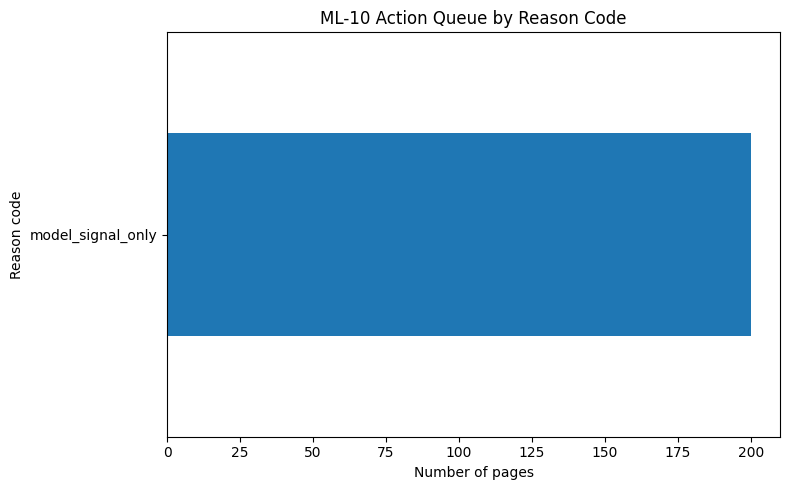

In [31]:

#  Reason-code figure


reason_counts = (
    queue_df["reason_code"]
    .value_counts()
    .sort_values()
)

fig, ax = plt.subplots(
    figsize=(8, 5)
)

reason_counts.plot(
    kind="barh",
    ax=ax
)

ax.set_xlabel("Number of pages")
ax.set_ylabel("Reason code")
ax.set_title(
    "ML-10 Action Queue by Reason Code"
)

plt.tight_layout()

plt.savefig(
    "work/figures/reason_code_distribution.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [32]:
# ============================================================
# ML-10 SELF-CHECK
# ============================================================

print("ML-10 self-check")
print("=" * 50)

checks = {

    "Queue has 200 rows":
        len(queue_df) == 200,

    "Reason codes created":
        queue_df["reason_code"].notna().all(),

    "Recommended actions created":
        queue_df["recommended_action"].notna().all(),

    "Priority created":
        queue_df["priority"].notna().all(),

    "Human review flag created":
        queue_df["mandatory_human_review"].notna().all(),

    "Automation disabled":
        queue_df["automation_allowed"].eq(False).all(),

    "Queue CSV exists":
        os.path.exists(
            "work/outputs/ranked_action_queue.csv"
        ),

    "Metrics JSON exists":
        os.path.exists(
            "work/outputs/playbook_metrics.json"
        ),

    "Figure exists":
        os.path.exists(
            "work/figures/reason_code_distribution.png"
        )
}

for check, passed in checks.items():

    print(
        f"{'PASS' if passed else 'FAIL'}: "
        f"{check}"
    )

print("\nFinal summary")
print("-" * 50)

print("Queue rows:", len(queue_df))
print("Clients:", df["client_id"].nunique())

print(
    "Reason codes:",
    queue_df["reason_code"].nunique()
)

print(
    "Mandatory review:",
    queue_df["mandatory_human_review"].sum()
)

print(
    "Automatic actions allowed:",
    queue_df["automation_allowed"].any()
)

ML-10 self-check
PASS: Queue has 200 rows
PASS: Reason codes created
PASS: Recommended actions created
PASS: Priority created
PASS: Human review flag created
PASS: Automation disabled
PASS: Queue CSV exists
PASS: Metrics JSON exists
PASS: Figure exists

Final summary
--------------------------------------------------
Queue rows: 200
Clients: 41
Reason codes: 1
Mandatory review: 200
Automatic actions allowed: False


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.